<a href="https://colab.research.google.com/github/avram4uk/coursework/blob/main/%D0%B3%D0%BB%D0%B0%D0%B2%D0%B0_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/rusentiment_test.csv')
df

,label,text
0,neutral,"Александр, тебе к лицу эта пушка :)\n"
1,positive,"Скоро ты вернешься домой, грязный, не бритый н..."
2,neutral,помниш...))
3,skip,Мы просто с [id12210212|Елисеем] психанули )...
4,speech,"ой, прости забыла поздравить, с праздничьком, ..."
...,...,...
2962,neutral,Коллективно жмём F13! И наблюдаем за результатом!
2963,neutral,ану ка быстро цоя добавь!
2964,skip,Ты одна половинка - я вторая половинка...... А...
2965,positive,Люблю кису)))


In [ ]:
print("количество позитивных постов: ", len([i for i in df['label'] if i == "positive"]), "процентное соотношение: ",
      len([i for i in df['label'] if i == "positive"]) / 2967 * 100)
print("количество негативных постов: ", len([i for i in df['label'] if i == "negative"]), "процентное соотношение: ",
      len([i for i in df['label'] if i == "negative"]) / 2967 * 100)
print("количество нейтральных постов: ", len([i for i in df['label'] if i == "neutral"]), "процентное соотношение: ",
      len([i for i in df['label'] if i == "neutral"]) / 2967 * 100)
print("количество постов с меткой 'skip': ", len([i for i in df['label'] if i == "skip"]), "процентное соотношение: ",
      len([i for i in df['label'] if i == "skip"]) / 2967 * 100)
print("количество постов с меткой 'speech': ", len([i for i in df['label'] if i == "speech"]), "процентное соотношение: ",
      len([i for i in df['label'] if i == "speech"]) / 2967 * 100)
count = 0
for i in df['text']:
  count += len(i)
srednee = count / 2967
print("среднее количество символов в посте: ", srednee)

количество позитивных постов:  536 процентное соотношение:  18.065385911695316
количество негативных постов:  258 процентное соотношение:  8.695652173913043
количество нейтральных постов:  1420 процентное соотношение:  47.8597910347152
количество постов с меткой 'skip':  346 процентное соотношение:  11.661611054937646
количество постов с меткой 'speech':  407 процентное соотношение:  13.717559824738792
среднее количество символов в посте:  78.39568587799124


In [ ]:
import re

def clean_text(text):
    text = text.lower()                    # Всё в нижний регистр
    text = re.sub(r'[^а-яё ]', '', text)   # Удаляем всё, кроме русских букв и пробелов
    text = ' '.join(text.split())          # Убираем лишние пробелы
    return text

df['clean_text'] = df['text'].apply(clean_text)

# Покажем, как изменился текст
print(f"До:  {df['text'].iloc[0]}{df['text'].iloc[1]}\n{df['text'].iloc[4]}")
print(f"После: {df['clean_text'].iloc[0]}\n{df['clean_text'].iloc[1]}\n{df['clean_text'].iloc[4]}")

До:  Александр, тебе к лицу эта пушка :)
Скоро ты вернешься домой, грязный, не бритый но такой любимый ❤
ой, прости забыла поздравить, с праздничьком, да ! ))))
После: александр тебе к лицу эта пушка
скоро ты вернешься домой грязный не бритый но такой любимый
ой прости забыла поздравить с праздничьком да


In [ ]:
# Установка библиотеки (раскомментируйте и запустите один! раз)
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 37.2 MB/s eta 0:00:00


In [ ]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

def lemmatize_text(text):
    """
    Разбивает текст на слова и каждое слово приводит к начальной форме.
    """
    words = text.split()                                           # Разбиваем на слова
    lemmas = [morph.parse(word)[0].normal_form for word in words]  # Лемматизируем каждое
    return ' '.join(lemmas)                                        # Собираем обратно в строку

# Применяем функцию ко всем текстам в датасете
df['lemmas'] = df['clean_text'].apply(lemmatize_text)

# Покажем, как изменился текст
print(f"До:  {df['clean_text'].iloc[0]}\n{df['clean_text'].iloc[1]}\n{df['clean_text'].iloc[4]}")
print(f"После: {df['lemmas'].iloc[0]}\n{df['lemmas'].iloc[1]}\n{df['lemmas'].iloc[4]}")

До:  александр тебе к лицу эта пушка
скоро ты вернешься домой грязный не бритый но такой любимый
ой прости забыла поздравить с праздничьком да
После: александр ты к лицо этот пушка
скоро ты вернуться домой грязный не бритый но такой любимый
ой простить забыть поздравить с праздничький да


In [ ]:
from collections import Counter

# Объединяем все леммы в один список слов
all_words = ' '.join(df['lemmas']).split()

# Считаем частоту каждого слова
word_counts = Counter(all_words)

print("Топ-10 самых частых слов:")
for word, count in word_counts.most_common(10):
    print(f"{word}: {count}")

Топ-10 самых частых слов:
и: 941
в: 884
я: 726
не: 684
с: 636
ты: 581
на: 500
быть: 358
что: 338
день: 314


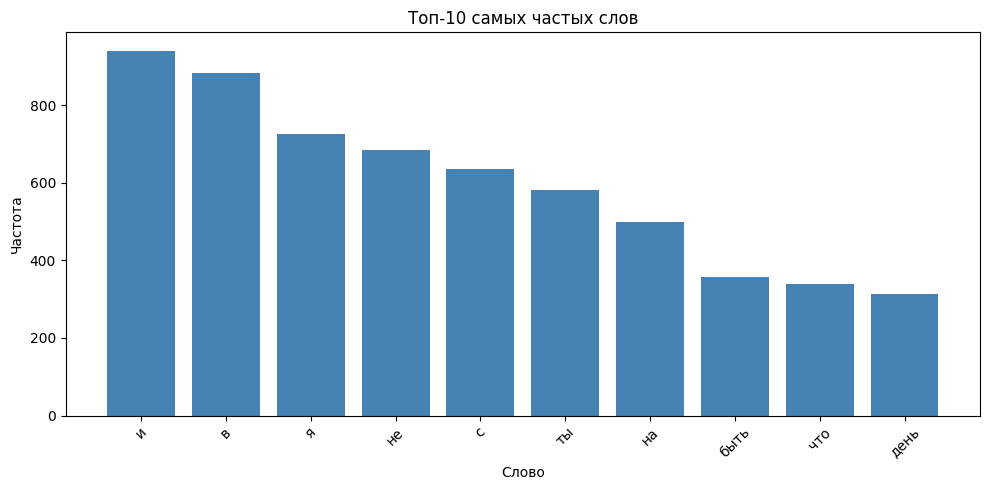

In [ ]:
# Строим столбчатый график топ-10 слов
import matplotlib.pyplot as plt

# Берём топ-10 и разделяем на слова и частоты
top_words = word_counts.most_common(10)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Топ-10 самых частых слов')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Установка (один раз)
!pip install wordcloud

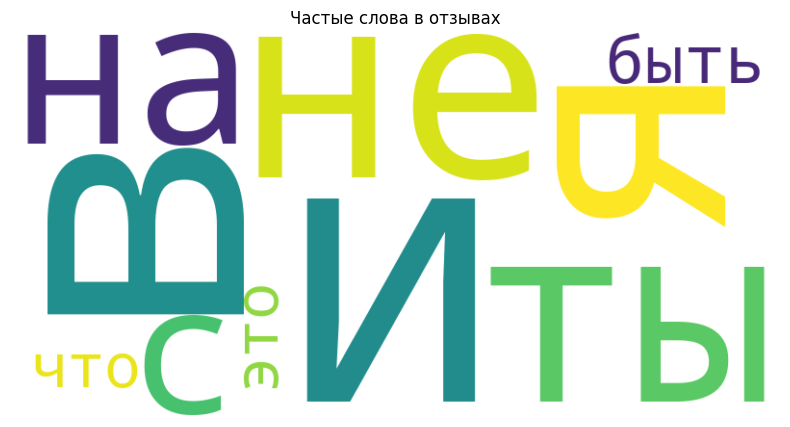

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Создаём облако слов
all_text = ' '.join(df['lemmas'])
wc = WordCloud(width=800, height=400,  max_words=10, background_color='white').generate(all_text)

# Показываем
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Частые слова в отзывах')
plt.show()

In [ ]:
import nltk
from nltk.corpus import stopwords

# Скачиваем список стоп-слов
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Топ-10 самых частых слов после удаления:
день: 314
это: 277
весь: 227
всё: 219
хороший: 143
рождение: 143
любить: 119
свой: 114
человек: 104
жизнь: 103
-----------------------------------------
До:  александр ты к лицо этот пушка
скоро ты вернуться домой грязный не бритый но такой любимый
ой простить забыть поздравить с праздничький да
После: александр лицо пушка
скоро вернуться домой грязный бритый любимый
ой простить забыть поздравить праздничький


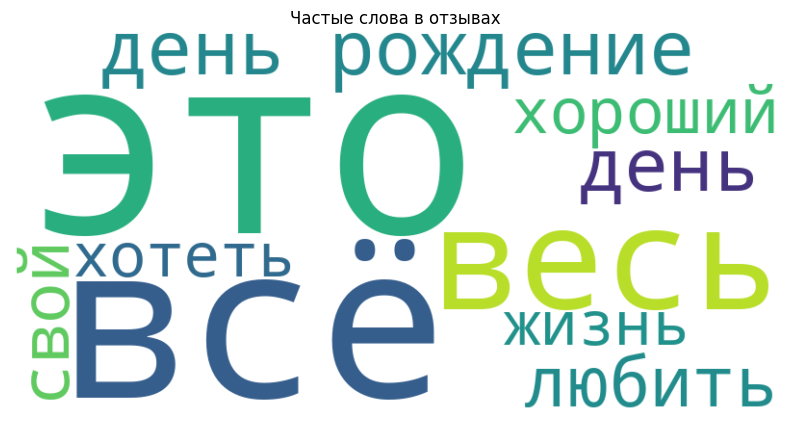

In [ ]:
stop_words = set(stopwords.words('russian'))         # загружаем русские стоп-слова

# удаляем стоп-слова из наших лемматизированных текстов
def remove_stopwords(text, stop_words):
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words])

df['no_stopwords'] = df['lemmas'].apply(lambda x: remove_stopwords(x, stop_words))

all_words = ' '.join(df['no_stopwords']).split()

# Считаем частоту каждого слова
word_counts = Counter(all_words)

print("Топ-10 самых частых слов после удаления:")
for word, count in word_counts.most_common(10):
    print(f"{word}: {count}")

# Покажем, как изменился текст
print("-----------------------------------------")
print(f"До:  {df['lemmas'].iloc[0]}\n{df['lemmas'].iloc[1]}\n{df['lemmas'].iloc[4]}")
print(f"После: {df['no_stopwords'].iloc[0]}\n{df['no_stopwords'].iloc[1]}\n{df['no_stopwords'].iloc[4]}")

# Создаём облако слов
all_text = ' '.join(df['no_stopwords'])
wc = WordCloud(width=800, height=400,  max_words=10, background_color='white').generate(all_text)

# Показываем
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Частые слова в отзывах')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# создаём и обучаем векторайзер
vectorizer = TfidfVectorizer(stop_words=list(stop_words))  # обычно именно тут удаляют стоп-слова, а не ранее, как это сделали мы
tfidf_matrix = vectorizer.fit_transform(df['no_stopwords'])

# получаем список всех слов (словарь)
feature_names = vectorizer.get_feature_names_out()
print(f"Размер словаря: {len(feature_names)} слов")

# наш первый текст в виде вектора
print(f"Текст: {df['no_stopwords'].iloc[0]}")
print(f"Вектор:\n{tfidf_matrix[0].toarray()}")

Размер словаря: 9036 слов
Текст: александр лицо пушка
Вектор:
[[0. 0. 0. ... 0. 0. 0.]]


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# функция поиска наиболее близких текстов к запросу
def search_texts(query, vectorizer, tfidf_matrix, texts, top_n=3):
    """
    Ищет top_n текстов, наиболее похожих на запрос.
    """
    query = clean_text(query)            # очищаем запрос
    query = lemmatize_text(query)        # лемматизируем запрос
    query_vec = vectorizer.transform([query])  # векторизуем запрос

    # считаем похожесть запроса со всеми текстами
    similarities = cosine_similarity(query_vec, tfidf_matrix)[0]

    # находим индексы топ-n самых похожих
    top_indices = similarities.argsort()[-top_n:][::-1]

    results = []
    for idx in top_indices:
        results.append({
            'Текст': texts.iloc[idx],
            'Похожесть': similarities[idx]
        })

    return results

In [ ]:
# Пример поиска
query = "сидеть дома"
results = search_texts(query, vectorizer, tfidf_matrix, df['no_stopwords'], top_n=3)

print(f"Поисковый запрос: '{query}'")
print(f"\nНайдено {len(results)} наиболее похожих отзывов:\n")
for i, res in enumerate(results, 1):
    print(f"{i}. Похожесть: {res['Похожесть']:.8f}")
    print(f"   Текст: {res['Текст']}")

Поисковый запрос: 'сидеть дома'

Найдено 3 наиболее похожих отзывов:

1. Похожесть: 0.50269188
   Текст: урок сидеть
2. Похожесть: 0.50114286
   Текст: наш дом
3. Похожесть: 0.36918595
   Текст: сержант дом
